# Generate fake Fashion MNIST images
In this project you must develop a Conditional Generative Adversarial Neural Network (CGAN) model to generate fake images of the following 3 items: *Trouser* (labeled **1**), Pullover (labeled **2**), and Sneaker (labeled **7**) in the dataset by training your model using images from the [Fashion MNIST](https://keras.io/api/datasets/fashion_mnist/) dataset.


## Import

In [ ]:
# You may modify this cell as needed
import os
import glob
import keras
from keras import layers
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt


## Get data
Use the function *get_data()* to obtain images of Trousers, Pullovers, and Sneakers relabeled 0, 1, 2.

In [ ]:
def get_data():
  """Returns images of Trousers, Pullovers, and Sneakers relabeled 0, 1, 2"""
  (x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()
  all_images = np.concatenate([x_train, x_test])
  all_labels = np.concatenate([y_train, y_test])
  retained_indices = np.where(np.isin(all_labels, [1, 2, 7]))
  retained_images = all_images[retained_indices]
  retained_labels = all_labels[retained_indices]
  # Map labels to new values
  label_mapping = {1: 0, 2: 1, 7: 2}
  mapped_labels = np.vectorize(label_mapping.get)(retained_labels)
  ITEMS = ['Trouser', 'Pullover', 'Sneaker']
  return retained_images, mapped_labels, ITEMS

all_images, all_class_labels, ITEMS = get_data()

print(f'Shape of images: {all_images.shape}')
print(f'Shape of labels: {all_class_labels.shape}')
print(f'Unique labels: {np.unique(all_class_labels)}')
print(f'Items: {[(i, item) for i,item in enumerate(ITEMS)]}')

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Shape of images: (21000, 28, 28)
Shape of labels: (21000,)
Unique labels: [0 1 2]
Items: [(0, 'Trouser'), (1, 'Pullover'), (2, 'Sneaker')]


## Display images
You may use the function *displayImages* to display images

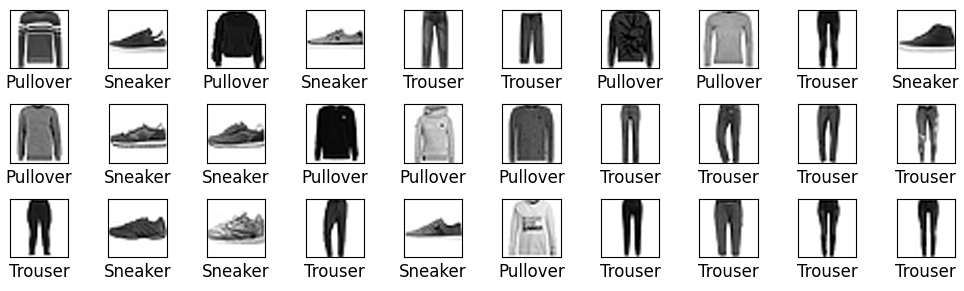

In [ ]:
def displayImages(images, labels, nCols=10):
    """Displays images with labels (nCols per row)"""
    nRows = np.ceil(len(labels)/nCols).astype('int') # number of rows
    plt.figure(figsize=(nCols,nRows)) # figure size
    for i in range(len(labels)):
        plt.subplot(nRows,nCols,i+1)
        plt.xticks([])
        plt.yticks([])
        plt.grid(False)
        plt.imshow(images[i], interpolation='spline16', cmap='gray_r')
        plt.xlabel(f'{labels[i]}', fontsize=12)
    plt.tight_layout()
    plt.show()
    return

# display the first k images with labels
k = 30
images = all_images[:k]
labels = [ITEMS[label] for label in all_class_labels[:k]]
displayImages(images, labels)

## Specify parameters [2 Points]
Specify parameters to create your CGAN model in the code cell below

In [ ]:
# Define parameters for the CGAN model
batch_size = 128
num_channels = 1
num_classes = 3
image_size = 28
latent_dim = 100

# Learning parameters
learning_rate = 0.0002
beta_1 = 0.5  # Adam optimizer parameter
beta_2 = 0.999  # Adam optimizer parameter

# Image shape
img_shape = (image_size, image_size, num_channels)

# Optimizer
discriminator_optimizer = keras.optimizers.Adam(learning_rate=learning_rate, beta_1=beta_1, beta_2=beta_2)
generator_optimizer = keras.optimizers.Adam(learning_rate=learning_rate, beta_1=beta_1, beta_2=beta_2)



## Preprocess [3 Points]
Type in the code to preprocess the data in the code cell below. Scale the pixel values of images to [0, 1] range, add a channel dimension to the images, and one-hot encode the labels. Print the shape of processed images and the shape of processed labels.

In [ ]:
# Scale pixel values to [0, 1] range
images = all_images.astype("float32") / 255.0

# Add channel dimension (28, 28) -> (28, 28, 1)
images = np.expand_dims(images, axis=-1)

# One-hot encode the labels
labels = keras.utils.to_categorical(all_class_labels, num_classes=3)

# Print the shapes of the processed data
print(f"Processed images shape: {images.shape}")
print(f"Processed labels shape: {labels.shape}")

Processed images shape: (21000, 28, 28, 1)
Processed labels shape: (21000, 3)


## Create discriminator [5 Points]
In the code cell below create your discriminator model, print the shape of the model input, and display the summary of the model.

In [ ]:
def create_discriminator():
    # Input layers for image and label
    img_input = layers.Input(shape=img_shape)
    label_input = layers.Input(shape=(num_classes,))

    # Process image through convolutional layers
    x = layers.Conv2D(64, kernel_size=4, strides=2, padding="same")(img_input)
    x = layers.LeakyReLU(alpha=0.2)(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Conv2D(128, kernel_size=4, strides=2, padding="same")(x)
    x = layers.LeakyReLU(alpha=0.2)(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Conv2D(256, kernel_size=4, strides=2, padding="same")(x)
    x = layers.LeakyReLU(alpha=0.2)(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Flatten()(x)

    # Process label and concatenate with flattened image
    y = layers.Dense(256)(label_input)
    y = layers.LeakyReLU(alpha=0.2)(y)

    # Concatenate image and label representations
    combined = layers.Concatenate()([x, y])

    # Output layer - binary classification (real/fake)
    output = layers.Dense(1, activation="sigmoid")(combined)

    # Create model
    model = keras.Model([img_input, label_input], output, name="discriminator")
    model.compile(
        loss="binary_crossentropy",
        optimizer=discriminator_optimizer,
        metrics=["accuracy"]
    )

    return model

# Create the discriminator
discriminator = create_discriminator()

# Print input shape
print(f"Discriminator input image shape: {img_shape}")
print(f"Discriminator input label shape: ({num_classes},)")

# Display model summary
discriminator.summary()

Discriminator input image shape: (28, 28, 1)
Discriminator input label shape: (3,)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "discriminator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 28, 28, 1)      │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d (Conv2D)           │ (None, 14, 14, 64)     │          1,088 │ input_layer[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ leaky_re_lu (LeakyReLU)   │ (None, 14, 14, 64)     │              0 │ conv2d[0][0]           │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout (Dropout)         │ (None, 14, 14, 64)     │              0 │ leaky_re_lu[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_1 (Conv2D)         │ (None, 7, 7, 128)      │        131,200 │ dropout[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ leaky_re_lu_1 (LeakyReLU) │ (None, 7, 7, 128)      │              0 │ conv2d_1[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_1 (Dropout)       │ (None, 7, 7, 128)      │              0 │ leaky_re_lu_1[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_2 (Conv2D)         │ (None, 4, 4, 256)      │        524,544 │ dropout_1[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ leaky_re_lu_2 (LeakyReLU) │ (None, 4, 4, 256)      │              0 │ conv2d_2[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ input_layer_1             │ (None, 3)              │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_2 (Dropout)       │ (None, 4, 4, 256)      │              0 │ leaky_re_lu_2[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense (Dense)             │ (None, 256)            │          1,024 │ input_layer_1[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ flatten (Flatten)         │ (None, 4096)           │              0 │ dropout_2[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ leaky_re_lu_3 (LeakyReLU) │ (None, 256)            │              0 │ dense[0][0]            │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ concatenate (Concatenate) │ (None, 4352)           │              0 │ flatten[0][0],         │
│                           │                        │                │ leaky_re_lu_3[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_1 (Dense)           │ (None, 1)              │          4,353 │ concatenate[0][0]      │
└───────────────────────────┴────────────────────────┴────────────────┴────────────────────────┘

 Total params: 662,209 (2.53 MB)

 Trainable params: 662,209 (2.53 MB)

 Non-trainable params: 0 (0.00 B)

## Create generator [5 Points]
In the code cell below create your generator model, print the shape of the model input, and display the summary of the model.

In [ ]:
def create_generator():
    # Input layers for noise and label
    noise_input = layers.Input(shape=(latent_dim,))
    label_input = layers.Input(shape=(num_classes,))

    # Process noise
    x = layers.Dense(7 * 7 * 256)(noise_input)
    x = layers.LeakyReLU(alpha=0.2)(x)
    x = layers.Reshape((7, 7, 256))(x)

    # Process label
    y = layers.Dense(7 * 7 * 256)(label_input)
    y = layers.LeakyReLU(alpha=0.2)(y)
    y = layers.Reshape((7, 7, 256))(y)

    # Combine noise and label
    combined = layers.Concatenate(axis=-1)([x, y])

    # Upsampling layers
    x = layers.Conv2DTranspose(128, kernel_size=4, strides=1, padding="same")(combined)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(alpha=0.2)(x)

    x = layers.Conv2DTranspose(128, kernel_size=4, strides=2, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(alpha=0.2)(x)

    x = layers.Conv2DTranspose(64, kernel_size=4, strides=2, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(alpha=0.2)(x)

    # Output layer - generates image with tanh activation
    output = layers.Conv2D(num_channels, kernel_size=4, padding="same", activation="tanh")(x)

    # Create model
    model = keras.Model([noise_input, label_input], output, name="generator")

    return model

# Create the generator
generator = create_generator()

# Print input shape
print(f"Generator input noise shape: ({latent_dim},)")
print(f"Generator input label shape: ({num_classes},)")

# Display model summary
generator.summary()

Generator input noise shape: (100,)
Generator input label shape: (3,)


Model: "generator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2             │ (None, 100)            │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ input_layer_3             │ (None, 3)              │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_2 (Dense)           │ (None, 12544)          │      1,266,944 │ input_layer_2[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_3 (Dense)           │ (None, 12544)          │         50,176 │ input_layer_3[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ leaky_re_lu_4 (LeakyReLU) │ (None, 12544)          │              0 │ dense_2[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ leaky_re_lu_5 (LeakyReLU) │ (None, 12544)          │              0 │ dense_3[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ reshape (Reshape)         │ (None, 7, 7, 256)      │              0 │ leaky_re_lu_4[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ reshape_1 (Reshape)       │ (None, 7, 7, 256)      │              0 │ leaky_re_lu_5[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ concatenate_1             │ (None, 7, 7, 512)      │              0 │ reshape[0][0],         │
│ (Concatenate)             │                        │                │ reshape_1[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_transpose          │ (None, 7, 7, 128)      │      1,048,704 │ concatenate_1[0][0]    │
│ (Conv2DTranspose)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization       │ (None, 7, 7, 128)      │            512 │ conv2d_transpose[0][0] │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ leaky_re_lu_6 (LeakyReLU) │ (None, 7, 7, 128)      │              0 │ batch_normalization[0… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_transpose_1        │ (None, 14, 14, 128)    │        262,272 │ leaky_re_lu_6[0][0]    │
│ (Conv2DTranspose)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_1     │ (None, 14, 14, 128)    │            512 │ conv2d_transpose_1[0]… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ leaky_re_lu_7 (LeakyReLU) │ (None, 14, 14, 128)    │              0 │ batch_normalization_1… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_transpose_2        │ (None, 28, 28, 64)     │        131,136 │ leaky_re_lu_7[0][0]    │
│ (Conv2DTranspose)    

 Total params: 2,761,537 (10.53 MB)

 Trainable params: 2,760,897 (10.53 MB)

 Non-trainable params: 640 (2.50 KB)

## Create ConditionalGAN model [5 Points]
In the code cell below specify the create your conditional GAN model, and display the summary of the model.

In [ ]:
class ConditionalGAN(keras.Model):
    def __init__(self, discriminator, generator, latent_dim):
        super().__init__()
        self.discriminator = discriminator
        self.generator = generator
        self.latent_dim = latent_dim
        self.gen_loss_tracker = keras.metrics.Mean(name="generator_loss")
        self.disc_loss_tracker = keras.metrics.Mean(name="discriminator_loss")

    @property
    def metrics(self):
        return [self.gen_loss_tracker, self.disc_loss_tracker]

    def compile(self, d_optimizer, g_optimizer, loss_fn):
        super().compile()
        self.d_optimizer = d_optimizer
        self.g_optimizer = g_optimizer
        self.loss_fn = loss_fn

    def train_step(self, data):
        # Unpack data
        real_images, real_labels = data
        batch_size = tf.shape(real_images)[0]

        # Train the discriminator first - on real images
        with tf.GradientTape() as tape:
            # Get predicted real/fake probability for real images
            pred_real = self.discriminator([real_images, real_labels])
            # Real images should be classified as real (1)
            d_loss_real = self.loss_fn(tf.ones((batch_size, 1)), pred_real)

            # Generate noise
            noise = tf.random.normal(shape=(batch_size, self.latent_dim))
            # Generate fake images
            fake_images = self.generator([noise, real_labels])
            # Get predicted real/fake probability for fake images
            pred_fake = self.discriminator([fake_images, real_labels])
            # Fake images should be classified as fake (0)
            d_loss_fake = self.loss_fn(tf.zeros((batch_size, 1)), pred_fake)

            # Total discriminator loss
            d_loss = d_loss_real + d_loss_fake

        # Get gradients and update discriminator weights
        grads = tape.gradient(d_loss, self.discriminator.trainable_weights)
        self.d_optimizer.apply_gradients(zip(grads, self.discriminator.trainable_weights))

        # Train the generator
        with tf.GradientTape() as tape:
            # Generate new noise
            noise = tf.random.normal(shape=(batch_size, self.latent_dim))
            # Generate fake images
            fake_images = self.generator([noise, real_labels])
            # Get predicted real/fake probability for fake images
            pred_fake = self.discriminator([fake_images, real_labels])
            # Generator wants fake images to be classified as real (1)
            g_loss = self.loss_fn(tf.ones((batch_size, 1)), pred_fake)

        # Get gradients and update generator weights
        grads = tape.gradient(g_loss, self.generator.trainable_weights)
        self.g_optimizer.apply_gradients(zip(grads, self.generator.trainable_weights))

        # Update metrics
        self.gen_loss_tracker.update_state(g_loss)
        self.disc_loss_tracker.update_state(d_loss)

        return {
            "g_loss": self.gen_loss_tracker.result(),
            "d_loss": self.disc_loss_tracker.result(),
        }

# Create the CGAN model
cgan = ConditionalGAN(discriminator, generator, latent_dim)
cgan.compile(
    d_optimizer=discriminator_optimizer,
    g_optimizer=generator_optimizer,
    loss_fn=keras.losses.BinaryCrossentropy()
)

# Display the summary of the model
print("Conditional GAN Model Summary:")
print(f"Generator input shape: ({latent_dim},) + ({num_classes},)")
print(f"Discriminator input shape: {img_shape} + ({num_classes},)")
print(f"Generator output shape: {img_shape}")

Conditional GAN Model Summary:
Generator input shape: (100,) + (3,)
Discriminator input shape: (28, 28, 1) + (3,)
Generator output shape: (28, 28, 1)


## Function to generate fake images [5 Points]
In the code cell below define a function *generate_fake_images* that takes 2 arguments *CGAN_model* and *class_label_list* and returns fake images generated by the *CGAN_model* corresponding to the labels specified in the list *class_label_list*




In [ ]:
def generate_fake_images(CGAN_model, class_label_list):
    """
    Generate fake images using the generator of the CGAN model

    Args:
        CGAN_model: The trained CGAN model
        class_label_list: List of class labels for which to generate images

    Returns:
        Fake images corresponding to the specified class labels
    """
    # Convert class labels to numpy array
    class_labels = np.array(class_label_list)

    # Number of images to generate
    num_images = len(class_labels)

    # Generate random noise vectors
    noise = tf.random.normal(shape=(num_images, latent_dim))

    # Convert class labels to one-hot encoded format
    one_hot_labels = keras.utils.to_categorical(class_labels, num_classes=num_classes)

    # Generate fake images using the generator
    # Important fix: Use the generator correctly - both inputs need to be tensor
    noise_tensor = tf.convert_to_tensor(noise, dtype=tf.float32)
    label_tensor = tf.convert_to_tensor(one_hot_labels, dtype=tf.float32)
    fake_images = CGAN_model.generator([noise_tensor, label_tensor])

    # Convert from [-1, 1] to [0, 1] range if using tanh activation
    fake_images = (fake_images + 1) / 2.0

    # Convert to numpy array and reshape
    fake_images = fake_images.numpy()
    fake_images = np.reshape(fake_images, (num_images, image_size, image_size))

    return fake_images

# Test the function with random weights
test_class_labels = [0, 1, 2]  # One of each class
test_images = generate_fake_images(cgan, test_class_labels)
print(f"Generated images shape: {test_images.shape}")
print(f"For class labels: {test_class_labels}")
print(f"Min pixel value: {test_images.min()}, Max pixel value: {test_images.max()}")

Generated images shape: (3, 28, 28)
For class labels: [0, 1, 2]
Min pixel value: 0.4843139350414276, Max pixel value: 0.512262225151062


## Train model [5 Points]
In the code cell below type in your code to train the model over 30 epochs. After each epoch save the weights of the generator and display fake images generated for classes with labels specified in *class_label_list*.

class_label_list: [0, 0, 0, 1, 1, 1, 2, 2, 2]

Epoch 1/30
  Batch 0: d_loss = 1.3804, g_loss = 0.6746
  Batch 20: d_loss = 1.2809, g_loss = 0.7006
  Batch 40: d_loss = 1.2722, g_loss = 0.7040
  Batch 60: d_loss = 1.3038, g_loss = 0.7417
  Batch 80: d_loss = 1.3037, g_loss = 0.7627
  Batch 100: d_loss = 1.2750, g_loss = 0.7712
  Batch 120: d_loss = 1.2646, g_loss = 0.7828
  Batch 140: d_loss = 1.2627, g_loss = 0.7959
  Batch 160: d_loss = 1.2615, g_loss = 0.8047
  Epoch 1 avg losses: d_loss = 1.2831, g_loss = 0.7484


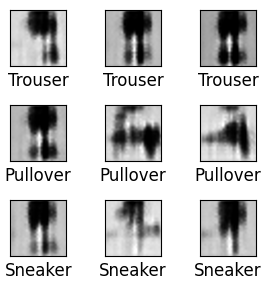

  Saved generator weights to generator_weights_epoch_1.weights.h5

Epoch 2/30
  Batch 0: d_loss = 1.2636, g_loss = 0.8047
  Batch 20: d_loss = 1.2655, g_loss = 0.8138
  Batch 40: d_loss = 1.2644, g_loss = 0.8170
  Batch 60: d_loss = 1.2638, g_loss = 0.8272
  Batch 80: d_loss = 1.2608, g_loss = 0.8316
  Batch 100: d_loss = 1.2574, g_loss = 0.8383
  Batch 120: d_loss = 1.2553, g_loss = 0.8464
  Batch 140: d_loss = 1.2525, g_loss = 0.8536
  Batch 160: d_loss = 1.2502, g_loss = 0.8576
  Epoch 2 avg losses: d_loss = 1.2595, g_loss = 0.8330


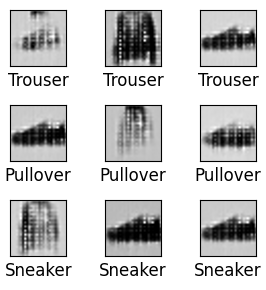

  Saved generator weights to generator_weights_epoch_2.weights.h5

Epoch 3/30
  Batch 0: d_loss = 1.2508, g_loss = 0.8593
  Batch 20: d_loss = 1.2491, g_loss = 0.8626
  Batch 40: d_loss = 1.2473, g_loss = 0.8662
  Batch 60: d_loss = 1.2471, g_loss = 0.8689
  Batch 80: d_loss = 1.2445, g_loss = 0.8711
  Batch 100: d_loss = 1.2434, g_loss = 0.8719
  Batch 120: d_loss = 1.2438, g_loss = 0.8727
  Batch 140: d_loss = 1.2426, g_loss = 0.8723
  Batch 160: d_loss = 1.2431, g_loss = 0.8735
  Epoch 3 avg losses: d_loss = 1.2456, g_loss = 0.8692


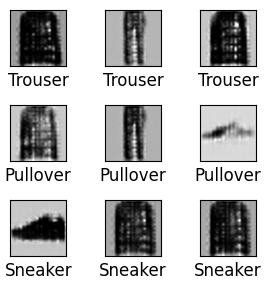

  Saved generator weights to generator_weights_epoch_3.weights.h5

Epoch 4/30
  Batch 0: d_loss = 1.2430, g_loss = 0.8742
  Batch 20: d_loss = 1.2426, g_loss = 0.8751
  Batch 40: d_loss = 1.2411, g_loss = 0.8764
  Batch 60: d_loss = 1.2395, g_loss = 0.8776
  Batch 80: d_loss = 1.2380, g_loss = 0.8801
  Batch 100: d_loss = 1.2362, g_loss = 0.8819
  Batch 120: d_loss = 1.2350, g_loss = 0.8839
  Batch 140: d_loss = 1.2343, g_loss = 0.8872
  Batch 160: d_loss = 1.2324, g_loss = 0.8898
  Epoch 4 avg losses: d_loss = 1.2380, g_loss = 0.8808


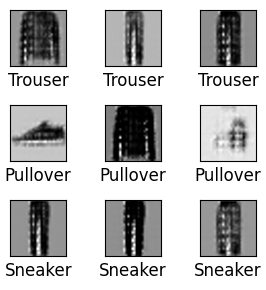

  Saved generator weights to generator_weights_epoch_4.weights.h5

Epoch 5/30
  Batch 0: d_loss = 1.2311, g_loss = 0.8904
  Batch 20: d_loss = 1.2304, g_loss = 0.8935
  Batch 40: d_loss = 1.2286, g_loss = 0.8960
  Batch 60: d_loss = 1.2280, g_loss = 0.8987
  Batch 80: d_loss = 1.2262, g_loss = 0.9012
  Batch 100: d_loss = 1.2249, g_loss = 0.9031
  Batch 120: d_loss = 1.2232, g_loss = 0.9046
  Batch 140: d_loss = 1.2215, g_loss = 0.9064
  Batch 160: d_loss = 1.2198, g_loss = 0.9091
  Epoch 5 avg losses: d_loss = 1.2259, g_loss = 0.9006


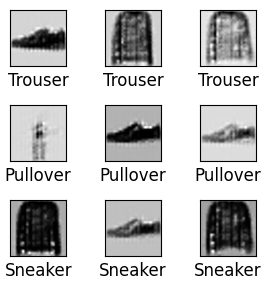

  Saved generator weights to generator_weights_epoch_5.weights.h5

Epoch 6/30
  Batch 0: d_loss = 1.2192, g_loss = 0.9091
  Batch 20: d_loss = 1.2169, g_loss = 0.9123
  Batch 40: d_loss = 1.2159, g_loss = 0.9146
  Batch 60: d_loss = 1.2138, g_loss = 0.9169
  Batch 80: d_loss = 1.2124, g_loss = 0.9200
  Batch 100: d_loss = 1.2106, g_loss = 0.9229
  Batch 120: d_loss = 1.2084, g_loss = 0.9254
  Batch 140: d_loss = 1.2073, g_loss = 0.9278
  Batch 160: d_loss = 1.2056, g_loss = 0.9305
  Epoch 6 avg losses: d_loss = 1.2120, g_loss = 0.9203


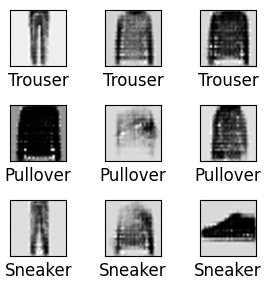

  Saved generator weights to generator_weights_epoch_6.weights.h5

Epoch 7/30
  Batch 0: d_loss = 1.2056, g_loss = 0.9309
  Batch 20: d_loss = 1.2035, g_loss = 0.9329
  Batch 40: d_loss = 1.2029, g_loss = 0.9347
  Batch 60: d_loss = 1.2010, g_loss = 0.9364
  Batch 80: d_loss = 1.1998, g_loss = 0.9389
  Batch 100: d_loss = 1.1977, g_loss = 0.9413
  Batch 120: d_loss = 1.1960, g_loss = 0.9434
  Batch 140: d_loss = 1.1942, g_loss = 0.9461
  Batch 160: d_loss = 1.1927, g_loss = 0.9482
  Epoch 7 avg losses: d_loss = 1.1990, g_loss = 0.9395


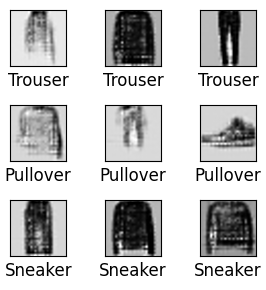

  Saved generator weights to generator_weights_epoch_7.weights.h5

Epoch 8/30
  Batch 0: d_loss = 1.1922, g_loss = 0.9488
  Batch 20: d_loss = 1.1898, g_loss = 0.9518
  Batch 40: d_loss = 1.1880, g_loss = 0.9542
  Batch 60: d_loss = 1.1866, g_loss = 0.9570
  Batch 80: d_loss = 1.1847, g_loss = 0.9599
  Batch 100: d_loss = 1.1830, g_loss = 0.9621
  Batch 120: d_loss = 1.1813, g_loss = 0.9647
  Batch 140: d_loss = 1.1798, g_loss = 0.9669
  Batch 160: d_loss = 1.1788, g_loss = 0.9692
  Epoch 8 avg losses: d_loss = 1.1847, g_loss = 0.9597


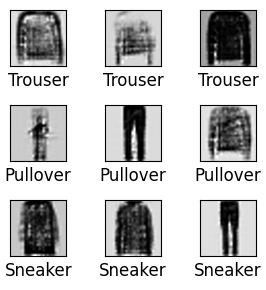

  Saved generator weights to generator_weights_epoch_8.weights.h5

Epoch 9/30
  Batch 0: d_loss = 1.1785, g_loss = 0.9701
  Batch 20: d_loss = 1.1768, g_loss = 0.9726
  Batch 40: d_loss = 1.1753, g_loss = 0.9754
  Batch 60: d_loss = 1.1731, g_loss = 0.9780
  Batch 80: d_loss = 1.1717, g_loss = 0.9809
  Batch 100: d_loss = 1.1707, g_loss = 0.9828
  Batch 120: d_loss = 1.1691, g_loss = 0.9853
  Batch 140: d_loss = 1.1682, g_loss = 0.9874
  Batch 160: d_loss = 1.1666, g_loss = 0.9892
  Epoch 9 avg losses: d_loss = 1.1720, g_loss = 0.9804


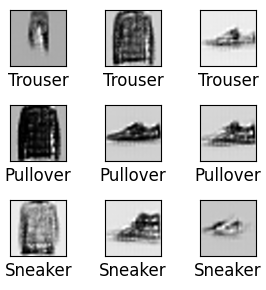

  Saved generator weights to generator_weights_epoch_9.weights.h5

Epoch 10/30
  Batch 0: d_loss = 1.1663, g_loss = 0.9900
  Batch 20: d_loss = 1.1647, g_loss = 0.9925
  Batch 40: d_loss = 1.1630, g_loss = 0.9946
  Batch 60: d_loss = 1.1619, g_loss = 0.9964
  Batch 80: d_loss = 1.1608, g_loss = 0.9980
  Batch 100: d_loss = 1.1597, g_loss = 0.9999
  Batch 120: d_loss = 1.1584, g_loss = 1.0023
  Batch 140: d_loss = 1.1574, g_loss = 1.0045
  Batch 160: d_loss = 1.1565, g_loss = 1.0068
  Epoch 10 avg losses: d_loss = 1.1608, g_loss = 0.9985


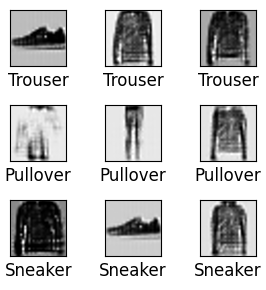

  Saved generator weights to generator_weights_epoch_10.weights.h5

Epoch 11/30
  Batch 0: d_loss = 1.1566, g_loss = 1.0072
  Batch 20: d_loss = 1.1551, g_loss = 1.0090
  Batch 40: d_loss = 1.1537, g_loss = 1.0115
  Batch 60: d_loss = 1.1530, g_loss = 1.0132
  Batch 80: d_loss = 1.1528, g_loss = 1.0148
  Batch 100: d_loss = 1.1510, g_loss = 1.0163
  Batch 120: d_loss = 1.1501, g_loss = 1.0182
  Batch 140: d_loss = 1.1494, g_loss = 1.0194
  Batch 160: d_loss = 1.1486, g_loss = 1.0204
  Epoch 11 avg losses: d_loss = 1.1521, g_loss = 1.0148


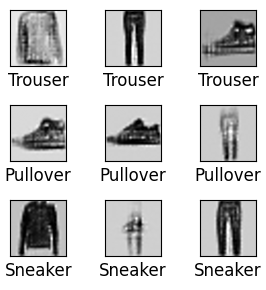

  Saved generator weights to generator_weights_epoch_11.weights.h5

Epoch 12/30
  Batch 0: d_loss = 1.1485, g_loss = 1.0208
  Batch 20: d_loss = 1.1476, g_loss = 1.0223
  Batch 40: d_loss = 1.1467, g_loss = 1.0238
  Batch 60: d_loss = 1.1459, g_loss = 1.0248
  Batch 80: d_loss = 1.1452, g_loss = 1.0257
  Batch 100: d_loss = 1.1445, g_loss = 1.0270
  Batch 120: d_loss = 1.1439, g_loss = 1.0283
  Batch 140: d_loss = 1.1437, g_loss = 1.0288
  Batch 160: d_loss = 1.1432, g_loss = 1.0295
  Epoch 12 avg losses: d_loss = 1.1454, g_loss = 1.0259


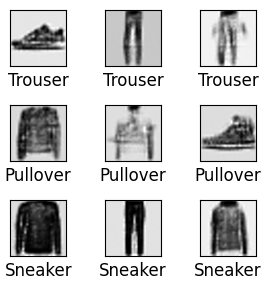

  Saved generator weights to generator_weights_epoch_12.weights.h5

Epoch 13/30
  Batch 0: d_loss = 1.1437, g_loss = 1.0300
  Batch 20: d_loss = 1.1434, g_loss = 1.0314
  Batch 40: d_loss = 1.1428, g_loss = 1.0323
  Batch 60: d_loss = 1.1420, g_loss = 1.0330
  Batch 80: d_loss = 1.1419, g_loss = 1.0337
  Batch 100: d_loss = 1.1415, g_loss = 1.0344
  Batch 120: d_loss = 1.1409, g_loss = 1.0350
  Batch 140: d_loss = 1.1405, g_loss = 1.0356
  Batch 160: d_loss = 1.1402, g_loss = 1.0358
  Epoch 13 avg losses: d_loss = 1.1419, g_loss = 1.0336


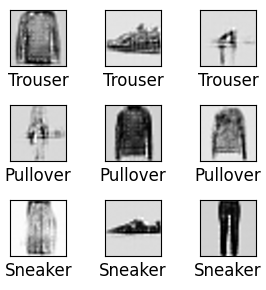

  Saved generator weights to generator_weights_epoch_13.weights.h5

Epoch 14/30
  Batch 0: d_loss = 1.1403, g_loss = 1.0359
  Batch 20: d_loss = 1.1396, g_loss = 1.0368
  Batch 40: d_loss = 1.1390, g_loss = 1.0377
  Batch 60: d_loss = 1.1388, g_loss = 1.0382
  Batch 80: d_loss = 1.1382, g_loss = 1.0390
  Batch 100: d_loss = 1.1378, g_loss = 1.0395
  Batch 120: d_loss = 1.1372, g_loss = 1.0399
  Batch 140: d_loss = 1.1370, g_loss = 1.0406
  Batch 160: d_loss = 1.1369, g_loss = 1.0414
  Epoch 14 avg losses: d_loss = 1.1382, g_loss = 1.0389


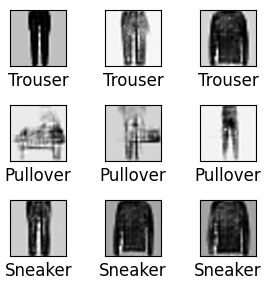

  Saved generator weights to generator_weights_epoch_14.weights.h5

Epoch 15/30
  Batch 0: d_loss = 1.1369, g_loss = 1.0414
  Batch 20: d_loss = 1.1366, g_loss = 1.0418
  Batch 40: d_loss = 1.1362, g_loss = 1.0424
  Batch 60: d_loss = 1.1360, g_loss = 1.0427
  Batch 80: d_loss = 1.1357, g_loss = 1.0427
  Batch 100: d_loss = 1.1350, g_loss = 1.0433
  Batch 120: d_loss = 1.1343, g_loss = 1.0443
  Batch 140: d_loss = 1.1335, g_loss = 1.0449
  Batch 160: d_loss = 1.1333, g_loss = 1.0455
  Epoch 15 avg losses: d_loss = 1.1352, g_loss = 1.0433


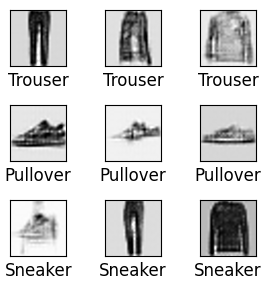

  Saved generator weights to generator_weights_epoch_15.weights.h5

Epoch 16/30
  Batch 0: d_loss = 1.1332, g_loss = 1.0457
  Batch 20: d_loss = 1.1328, g_loss = 1.0468
  Batch 40: d_loss = 1.1324, g_loss = 1.0473
  Batch 60: d_loss = 1.1320, g_loss = 1.0477
  Batch 80: d_loss = 1.1319, g_loss = 1.0482
  Batch 100: d_loss = 1.1314, g_loss = 1.0490
  Batch 120: d_loss = 1.1309, g_loss = 1.0496
  Batch 140: d_loss = 1.1305, g_loss = 1.0501
  Batch 160: d_loss = 1.1300, g_loss = 1.0506
  Epoch 16 avg losses: d_loss = 1.1316, g_loss = 1.0484


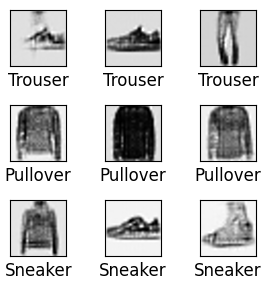

  Saved generator weights to generator_weights_epoch_16.weights.h5

Epoch 17/30
  Batch 0: d_loss = 1.1299, g_loss = 1.0508
  Batch 20: d_loss = 1.1297, g_loss = 1.0514
  Batch 40: d_loss = 1.1298, g_loss = 1.0517
  Batch 60: d_loss = 1.1294, g_loss = 1.0524
  Batch 80: d_loss = 1.1292, g_loss = 1.0526
  Batch 100: d_loss = 1.1289, g_loss = 1.0529
  Batch 120: d_loss = 1.1283, g_loss = 1.0533
  Batch 140: d_loss = 1.1279, g_loss = 1.0534
  Batch 160: d_loss = 1.1277, g_loss = 1.0539
  Epoch 17 avg losses: d_loss = 1.1290, g_loss = 1.0526


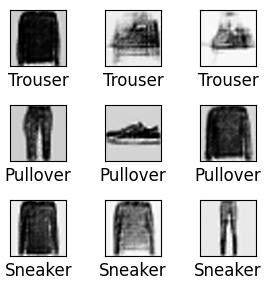

  Saved generator weights to generator_weights_epoch_17.weights.h5

Epoch 18/30
  Batch 0: d_loss = 1.1275, g_loss = 1.0539
  Batch 20: d_loss = 1.1270, g_loss = 1.0549
  Batch 40: d_loss = 1.1256, g_loss = 1.0572
  Batch 60: d_loss = 1.1254, g_loss = 1.0579
  Batch 80: d_loss = 1.1254, g_loss = 1.0583
  Batch 100: d_loss = 1.1251, g_loss = 1.0585
  Batch 120: d_loss = 1.1250, g_loss = 1.0590
  Batch 140: d_loss = 1.1246, g_loss = 1.0594
  Batch 160: d_loss = 1.1242, g_loss = 1.0600
  Epoch 18 avg losses: d_loss = 1.1255, g_loss = 1.0578


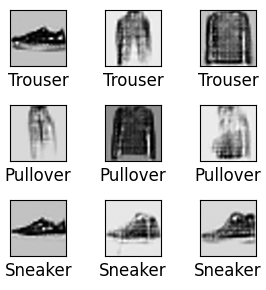

  Saved generator weights to generator_weights_epoch_18.weights.h5

Epoch 19/30
  Batch 0: d_loss = 1.1241, g_loss = 1.0600
  Batch 20: d_loss = 1.1240, g_loss = 1.0610
  Batch 40: d_loss = 1.1239, g_loss = 1.0612
  Batch 60: d_loss = 1.1240, g_loss = 1.0617
  Batch 80: d_loss = 1.1237, g_loss = 1.0621
  Batch 100: d_loss = 1.1234, g_loss = 1.0625
  Batch 120: d_loss = 1.1235, g_loss = 1.0628
  Batch 140: d_loss = 1.1233, g_loss = 1.0634
  Batch 160: d_loss = 1.1230, g_loss = 1.0635
  Epoch 19 avg losses: d_loss = 1.1237, g_loss = 1.0621


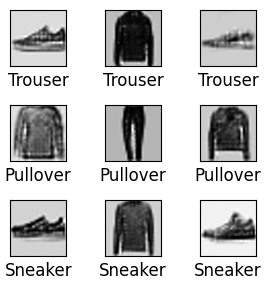

  Saved generator weights to generator_weights_epoch_19.weights.h5

Epoch 20/30
  Batch 0: d_loss = 1.1230, g_loss = 1.0635
  Batch 20: d_loss = 1.1227, g_loss = 1.0639
  Batch 40: d_loss = 1.1225, g_loss = 1.0644
  Batch 60: d_loss = 1.1221, g_loss = 1.0649
  Batch 80: d_loss = 1.1214, g_loss = 1.0663
  Batch 100: d_loss = 1.1210, g_loss = 1.0666
  Batch 120: d_loss = 1.1208, g_loss = 1.0672
  Batch 140: d_loss = 1.1205, g_loss = 1.0675
  Batch 160: d_loss = 1.1204, g_loss = 1.0676
  Epoch 20 avg losses: d_loss = 1.1216, g_loss = 1.0658


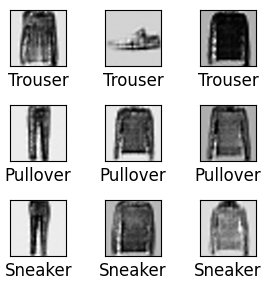

  Saved generator weights to generator_weights_epoch_20.weights.h5

Epoch 21/30
  Batch 0: d_loss = 1.1204, g_loss = 1.0678
  Batch 20: d_loss = 1.1201, g_loss = 1.0683
  Batch 40: d_loss = 1.1201, g_loss = 1.0685
  Batch 60: d_loss = 1.1199, g_loss = 1.0688
  Batch 80: d_loss = 1.1195, g_loss = 1.0692
  Batch 100: d_loss = 1.1189, g_loss = 1.0696
  Batch 120: d_loss = 1.1189, g_loss = 1.0698
  Batch 140: d_loss = 1.1189, g_loss = 1.0701
  Batch 160: d_loss = 1.1187, g_loss = 1.0703
  Epoch 21 avg losses: d_loss = 1.1194, g_loss = 1.0692


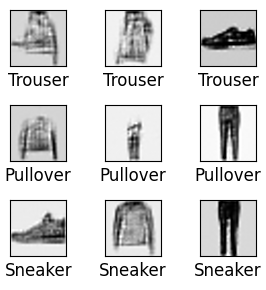

  Saved generator weights to generator_weights_epoch_21.weights.h5

Epoch 22/30
  Batch 0: d_loss = 1.1188, g_loss = 1.0706
  Batch 20: d_loss = 1.1189, g_loss = 1.0709
  Batch 40: d_loss = 1.1187, g_loss = 1.0711
  Batch 60: d_loss = 1.1183, g_loss = 1.0717
  Batch 80: d_loss = 1.1176, g_loss = 1.0724
  Batch 100: d_loss = 1.1173, g_loss = 1.0727
  Batch 120: d_loss = 1.1173, g_loss = 1.0731
  Batch 140: d_loss = 1.1172, g_loss = 1.0734
  Batch 160: d_loss = 1.1167, g_loss = 1.0737
  Epoch 22 avg losses: d_loss = 1.1178, g_loss = 1.0722


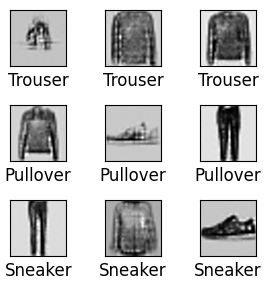

  Saved generator weights to generator_weights_epoch_22.weights.h5

Epoch 23/30
  Batch 0: d_loss = 1.1165, g_loss = 1.0741
  Batch 20: d_loss = 1.1155, g_loss = 1.0763
  Batch 40: d_loss = 1.1152, g_loss = 1.0770
  Batch 60: d_loss = 1.1150, g_loss = 1.0776
  Batch 80: d_loss = 1.1149, g_loss = 1.0781
  Batch 100: d_loss = 1.1148, g_loss = 1.0782
  Batch 120: d_loss = 1.1146, g_loss = 1.0786
  Batch 140: d_loss = 1.1144, g_loss = 1.0791
  Batch 160: d_loss = 1.1143, g_loss = 1.0792
  Epoch 23 avg losses: d_loss = 1.1149, g_loss = 1.0777


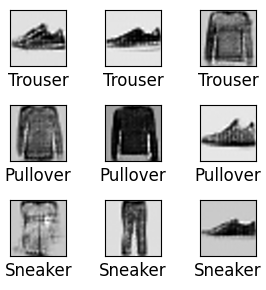

  Saved generator weights to generator_weights_epoch_23.weights.h5

Epoch 24/30
  Batch 0: d_loss = 1.1141, g_loss = 1.0793
  Batch 20: d_loss = 1.1140, g_loss = 1.0797
  Batch 40: d_loss = 1.1135, g_loss = 1.0802
  Batch 60: d_loss = 1.1136, g_loss = 1.0805
  Batch 80: d_loss = 1.1135, g_loss = 1.0807
  Batch 100: d_loss = 1.1134, g_loss = 1.0809
  Batch 120: d_loss = 1.1128, g_loss = 1.0815
  Batch 140: d_loss = 1.1128, g_loss = 1.0821
  Batch 160: d_loss = 1.1126, g_loss = 1.0827
  Epoch 24 avg losses: d_loss = 1.1133, g_loss = 1.0809


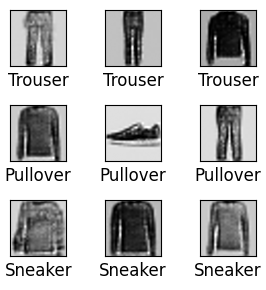

  Saved generator weights to generator_weights_epoch_24.weights.h5

Epoch 25/30
  Batch 0: d_loss = 1.1125, g_loss = 1.0829
  Batch 20: d_loss = 1.1122, g_loss = 1.0835
  Batch 40: d_loss = 1.1121, g_loss = 1.0839
  Batch 60: d_loss = 1.1116, g_loss = 1.0843
  Batch 80: d_loss = 1.1116, g_loss = 1.0846
  Batch 100: d_loss = 1.1113, g_loss = 1.0850
  Batch 120: d_loss = 1.1106, g_loss = 1.0862
  Batch 140: d_loss = 1.1108, g_loss = 1.0862
  Batch 160: d_loss = 1.1108, g_loss = 1.0863
  Epoch 25 avg losses: d_loss = 1.1115, g_loss = 1.0848


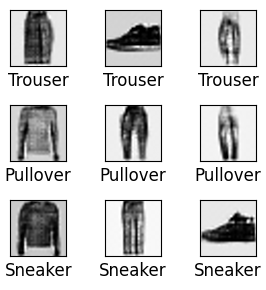

  Saved generator weights to generator_weights_epoch_25.weights.h5

Epoch 26/30
  Batch 0: d_loss = 1.1107, g_loss = 1.0864
  Batch 20: d_loss = 1.1103, g_loss = 1.0868
  Batch 40: d_loss = 1.1099, g_loss = 1.0877
  Batch 60: d_loss = 1.1091, g_loss = 1.0885
  Batch 80: d_loss = 1.1091, g_loss = 1.0889
  Batch 100: d_loss = 1.1090, g_loss = 1.0891
  Batch 120: d_loss = 1.1089, g_loss = 1.0892
  Batch 140: d_loss = 1.1086, g_loss = 1.0896
  Batch 160: d_loss = 1.1083, g_loss = 1.0902
  Epoch 26 avg losses: d_loss = 1.1093, g_loss = 1.0885


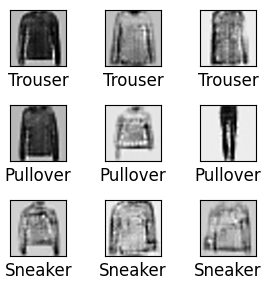

  Saved generator weights to generator_weights_epoch_26.weights.h5

Epoch 27/30
  Batch 0: d_loss = 1.1084, g_loss = 1.0902
  Batch 20: d_loss = 1.1084, g_loss = 1.0908
  Batch 40: d_loss = 1.1082, g_loss = 1.0913
  Batch 60: d_loss = 1.1077, g_loss = 1.0921
  Batch 80: d_loss = 1.1072, g_loss = 1.0931
  Batch 100: d_loss = 1.1071, g_loss = 1.0935
  Batch 120: d_loss = 1.1067, g_loss = 1.0940
  Batch 140: d_loss = 1.1067, g_loss = 1.0941
  Batch 160: d_loss = 1.1065, g_loss = 1.0941
  Epoch 27 avg losses: d_loss = 1.1074, g_loss = 1.0927


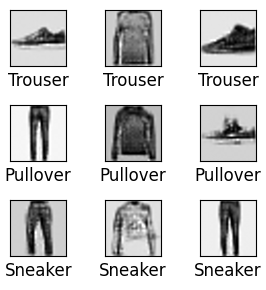

  Saved generator weights to generator_weights_epoch_27.weights.h5

Epoch 28/30
  Batch 0: d_loss = 1.1066, g_loss = 1.0940
  Batch 20: d_loss = 1.1066, g_loss = 1.0944
  Batch 40: d_loss = 1.1065, g_loss = 1.0946
  Batch 60: d_loss = 1.1065, g_loss = 1.0947
  Batch 80: d_loss = 1.1063, g_loss = 1.0950
  Batch 100: d_loss = 1.1063, g_loss = 1.0951
  Batch 120: d_loss = 1.1060, g_loss = 1.0954
  Batch 140: d_loss = 1.1058, g_loss = 1.0958
  Batch 160: d_loss = 1.1050, g_loss = 1.0968
  Epoch 28 avg losses: d_loss = 1.1062, g_loss = 1.0951


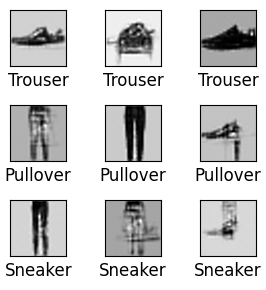

  Saved generator weights to generator_weights_epoch_28.weights.h5

Epoch 29/30
  Batch 0: d_loss = 1.1049, g_loss = 1.0971
  Batch 20: d_loss = 1.1049, g_loss = 1.0976
  Batch 40: d_loss = 1.1048, g_loss = 1.0979
  Batch 60: d_loss = 1.1047, g_loss = 1.0981
  Batch 80: d_loss = 1.1045, g_loss = 1.0981
  Batch 100: d_loss = 1.1042, g_loss = 1.0989
  Batch 120: d_loss = 1.1041, g_loss = 1.0992
  Batch 140: d_loss = 1.1039, g_loss = 1.0999
  Batch 160: d_loss = 1.1037, g_loss = 1.1003
  Epoch 29 avg losses: d_loss = 1.1044, g_loss = 1.0986


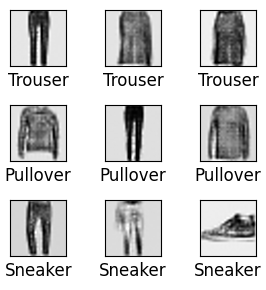

  Saved generator weights to generator_weights_epoch_29.weights.h5

Epoch 30/30
  Batch 0: d_loss = 1.1039, g_loss = 1.1005
  Batch 20: d_loss = 1.1038, g_loss = 1.1010
  Batch 40: d_loss = 1.1035, g_loss = 1.1013
  Batch 60: d_loss = 1.1034, g_loss = 1.1017
  Batch 80: d_loss = 1.1034, g_loss = 1.1022
  Batch 100: d_loss = 1.1033, g_loss = 1.1023
  Batch 120: d_loss = 1.1030, g_loss = 1.1027
  Batch 140: d_loss = 1.1029, g_loss = 1.1031
  Batch 160: d_loss = 1.1029, g_loss = 1.1035
  Epoch 30 avg losses: d_loss = 1.1033, g_loss = 1.1021


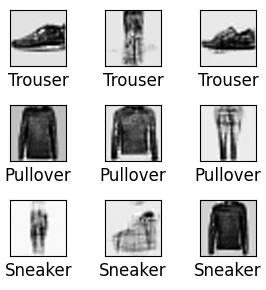

  Saved generator weights to generator_weights_epoch_30.weights.h5


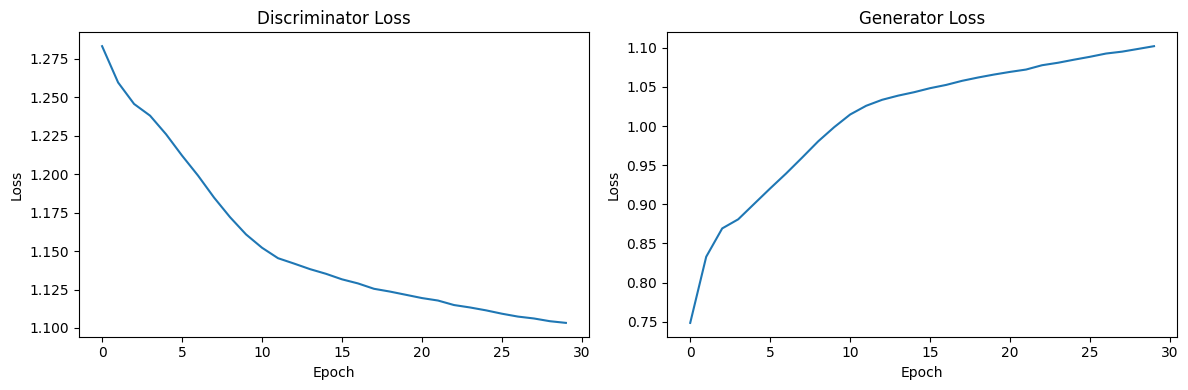

In [ ]:
class_label_list = 3*[0] + 3*[1] + 3*[2]
print(f"class_label_list: {class_label_list}")

# Define the number of epochs
epochs = 30

# Create a dataset for training
dataset = tf.data.Dataset.from_tensor_slices((images, labels))
dataset = dataset.shuffle(buffer_size=len(images))
dataset = dataset.batch(batch_size)

# Save progress every few epochs
save_interval = 5

# Lists to track metrics
d_losses = []
g_losses = []

for epoch in range(epochs):
    print(f"\nEpoch {epoch+1}/{epochs}")

    # Lists to store batch losses
    batch_d_losses = []
    batch_g_losses = []

    # Train on batches
    for batch_idx, (real_images, real_labels) in enumerate(dataset):
        # Train the model on this batch
        metrics = cgan.train_step((real_images, real_labels))

        # Store batch losses
        batch_d_losses.append(metrics["d_loss"])
        batch_g_losses.append(metrics["g_loss"])

        # Print progress periodically
        if batch_idx % 20 == 0:
            print(f"  Batch {batch_idx}: d_loss = {metrics['d_loss']:.4f}, g_loss = {metrics['g_loss']:.4f}")

    # Calculate average losses for this epoch
    avg_d_loss = sum(batch_d_losses) / len(batch_d_losses)
    avg_g_loss = sum(batch_g_losses) / len(batch_g_losses)

    # Append to metrics lists
    d_losses.append(avg_d_loss)
    g_losses.append(avg_g_loss)

    print(f"  Epoch {epoch+1} avg losses: d_loss = {avg_d_loss:.4f}, g_loss = {avg_g_loss:.4f}")

    # Generate and display fake images
    fake_images = generate_fake_images(cgan, class_label_list)
    item_labels = [ITEMS[label] for label in class_label_list]
    displayImages(fake_images, item_labels, nCols=3)

    # Save generator weights
    generator_weights_path = f"generator_weights_epoch_{epoch+1}.weights.h5"
    cgan.generator.save_weights(generator_weights_path)
    print(f"  Saved generator weights to {generator_weights_path}")

# Plot training losses
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(d_losses)
plt.title('Discriminator Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.subplot(1, 2, 2)
plt.plot(g_losses)
plt.title('Generator Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.tight_layout()
plt.show()

## Use trained generator [5 Points]
Create a generator with weights saved in an epoch that you consider generates the most authentic fake images and use it to generate fake digits for classes specified in class_label_list.

/usr/local/lib/python3.11/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Found weight files: ['generator_weights_epoch_13.weights.h5', 'generator_weights_epoch_19.weights.h5', 'generator_weights_epoch_4.weights.h5', 'generator_weights_epoch_12.weights.h5', 'generator_weights_epoch_18.weights.h5', 'generator_weights_epoch_8.weights.h5', 'generator_weights_epoch_22.weights.h5', 'generator_weights_epoch_2.weights.h5', 'generator_weights_epoch_29.weights.h5', 'generator_weights_epoch_24.weights.h5', 'generator_weights_epoch_16.weights.h5', 'generator_weights_epoch_9.weights.h5', 'generator_weights_epoch_7.weights.h5', 'generator_weights_epoch_1.weights.h5', 'generator_weights_epoch_20.weights.h5', 'generator_weights_epoch_5.weights.h5', 'generator_weights_epoch_27.weights.h5', 'generator_weights_epoch_30.weights.h5', 'generator_weights_epoch_15.weights.h5', 'generator_weights_epoch_10.weights.h5', 'generator_weights_epoch_28.weights.h5', 'generator_weights_epoch_14.weights.h5', 'generator_weights_epoch_11.weights.h5', 'generator_weights_epoch_6.weights.h5', 'ge

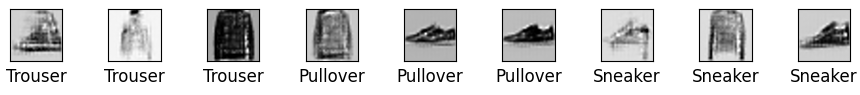

Real images for comparison:


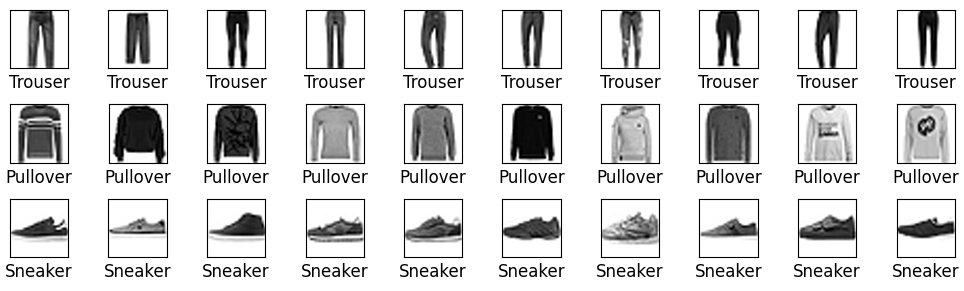

In [ ]:
# Choose the best epoch based on visual quality of generated images
best_epoch = 19  # This should be changed to the best epoch after training

# Recreate the generator model
best_generator = create_generator()

# Look for weight files in the current directory
weight_files = glob.glob("generator_weights_epoch_*.h5")
print(f"Found weight files: {weight_files}")

if weight_files:
    # If files exist, use the latest one (or specified one)
    if f"generator_weights_epoch_{best_epoch}.h5" in weight_files:
        generator_weights_path = f"generator_weights_epoch_{best_epoch}.h5"
    else:
        # Get the latest file by sorting
        generator_weights_path = sorted(weight_files)[-1]
        best_epoch = int(generator_weights_path.split('_')[-1].split('.')[0])
        print(f"Using latest available weights from epoch {best_epoch}")

    # Load the weights
    best_generator.load_weights(generator_weights_path)
    print(f"Successfully loaded weights from {generator_weights_path}")
else:
    print("No saved weights found. Using the current generator without loading weights.")
    # Use the current generator's weights (from the training session)
    best_generator = generator

# Create a simplified CGAN model for image generation
class SimpleGenerator:
    def __init__(self, generator):
        self.generator = generator

# Create a simple generator object
simple_cgan = SimpleGenerator(best_generator)

# Generate images using the trained generator
print(f"Generating images using the best model from epoch {best_epoch}...")
fake_images = generate_fake_images(simple_cgan, class_label_list)

# Display the generated images
item_labels = [ITEMS[label] for label in class_label_list]
displayImages(fake_images, item_labels, nCols=10)

# Compare with real images
num_samples = 10
real_images_to_display = []
real_labels_to_display = []

# Get samples of each class
for class_idx in range(num_classes):
    class_indices = np.where(all_class_labels == class_idx)[0][:num_samples]
    for idx in class_indices:
        real_images_to_display.append(all_images[idx])
        real_labels_to_display.append(ITEMS[all_class_labels[idx]])

# Display real images for comparison
print("Real images for comparison:")
displayImages(real_images_to_display, real_labels_to_display, nCols=10)